In [17]:

import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from xgboost import XGBClassifier
from sklearn import metrics
import matplotlib.pyplot as plt
import seaborn as sns


In [18]:
df = pd.read_csv('creditcard.csv')
df.shape

(284807, 31)

In [19]:
scaler = StandardScaler()
df['Amount_scaled'] = scaler.fit_transform(df[['Amount']])
df['Time_scaled'] = scaler.fit_transform(df[['Time']])
                                    

In [20]:
df = df.drop(['Time', 'Amount'], axis=1)

In [21]:
df.head()

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V22,V23,V24,V25,V26,V27,V28,Class,Amount_scaled,Time_scaled
0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,...,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,0,0.244964,-1.996583
1,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,...,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,0,-0.342475,-1.996583
2,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,...,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,0,1.160686,-1.996562
3,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,...,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,0,0.140534,-1.996562
4,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,...,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,0,-0.073403,-1.996541


In [22]:
X = df.drop('Class', axis=1)
y = df['Class']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(X_train.shape, X_test.shape, y_train.mean(), y_test.mean())

(227845, 30) (56962, 30) 0.001729245759178389 0.0017204452090867595


In [23]:
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train, y_train)
y_pred = log_reg.predict(X_test)
print(metrics.classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.83      0.64      0.72        98

    accuracy                           1.00     56962
   macro avg       0.91      0.82      0.86     56962
weighted avg       1.00      1.00      1.00     56962



In [24]:
log_reg_weighted = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
log_reg_weighted.fit(X_train, y_train)
y_pred_weighted = log_reg_weighted.predict(X_test)
print(metrics.classification_report(y_test, y_pred_weighted))

              precision    recall  f1-score   support

           0       1.00      0.98      0.99     56864
           1       0.06      0.92      0.11        98

    accuracy                           0.98     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.98      0.99     56962



In [25]:
smote = SMOTE(random_state=42)
x_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)
print('before smote:', y_train.value_counts().to_dict())
print('after smote:', y_train_smote.value_counts().to_dict())
log_reg_smote = LogisticRegression(max_iter=1000, random_state=42)
log_reg_smote.fit(x_train_smote, y_train_smote)
y_pred_smote = log_reg_smote.predict(X_test)
print(metrics.classification_report(y_test, y_pred_smote))

before smote: {0: 227451, 1: 394}
after smote: {0: 227451, 1: 227451}
              precision    recall  f1-score   support

           0       1.00      0.97      0.99     56864
           1       0.06      0.92      0.11        98

    accuracy                           0.97     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.97      0.99     56962



In [ ]:
xgb_model = XGBClassifier(random_state=42, eval_metric='logloss')
xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_test)
print(metrics.classification_report(y_test, y_pred_xgb))

c:\Users\Seid\AppData\Local\Programs\Python\Python314\Lib\site-packages\xgboost\training.py:200: UserWarning: [02:35:25] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:794: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.90      0.80      0.84        98

    accuracy                           1.00     56962
   macro avg       0.95      0.90      0.92     56962
weighted avg       1.00      1.00      1.00     56962



V14    0.668751
V10    0.173469
V2     0.079504
V12    0.015174
V27    0.011785
V17    0.005272
V8     0.004353
V11    0.004201
V4     0.003114
V28    0.002485
dtype: float32


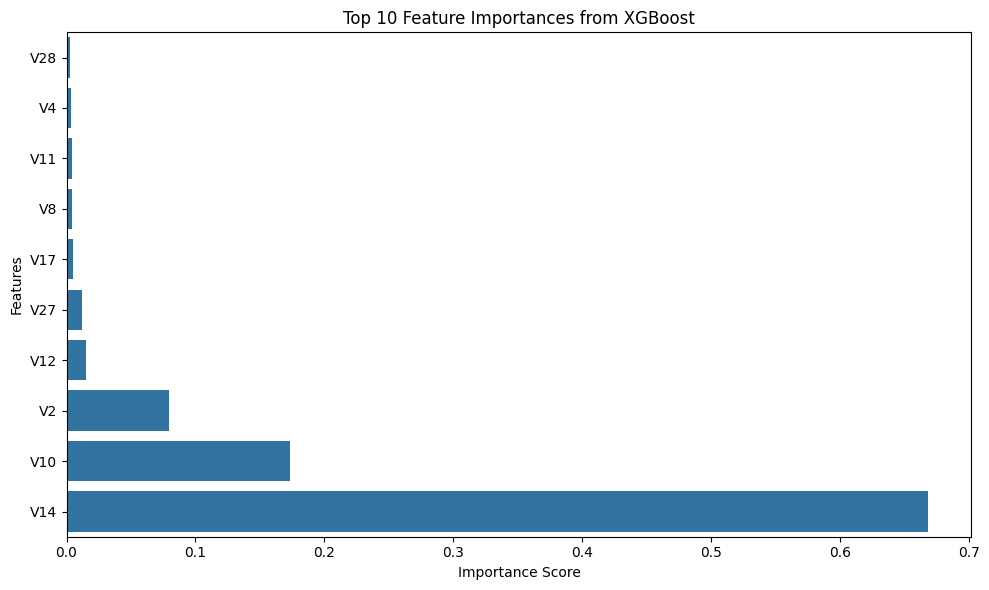

In [27]:
importances = pd.Series(xgb_model.feature_importances_, index=X_train.columns)
importances = importances.sort_values(ascending=False)
print(importances.head(10))
plt.figure(figsize=(10, 6))
sns.barplot(x=importances.head(10), y=importances.head(10).index)
plt.title('Top 10 Feature Importances from XGBoost')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

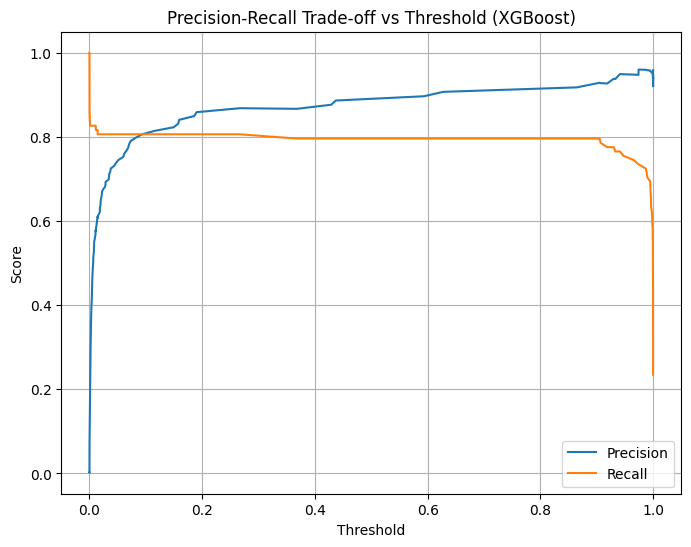

Average Precision (PR-AUC): 0.7813171412660339


In [31]:
y_scores = xgb_model.predict_proba(X_test)[:, 1]
precision, recall, thresholds = metrics.precision_recall_curve(y_test, y_scores)

plt.figure(figsize=(8, 6))
plt.plot(thresholds, precision[:-1], label='Precision')
plt.plot(thresholds, recall[:-1], label='Recall')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Precision-Recall Trade-off vs Threshold (XGBoost)')
plt.legend()
plt.grid(True)
plt.show()

avg_precision = metrics.average_precision_score(y_test, y_scores)
print('Average Precision (PR-AUC):', avg_precision)

In [29]:
custom_threshold = 0.7
y_pred_custom = (y_scores >= custom_threshold).astype(int)

print(metrics.classification_report(y_test, y_pred_custom))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.92      0.80      0.85        98

    accuracy                           1.00     56962
   macro avg       0.96      0.90      0.93     56962
weighted avg       1.00      1.00      1.00     56962



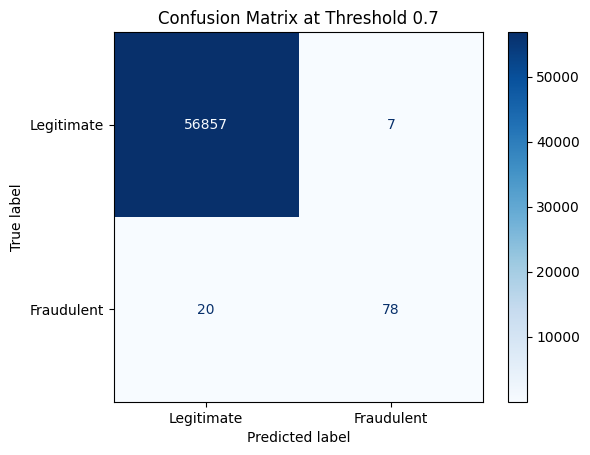

In [32]:
cm = metrics.confusion_matrix(y_test, y_pred_custom)
disp = metrics.ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Legitimate', 'Fraudulent'])
disp.plot(cmap=plt.cm.Blues)
disp.ax_.set_title(f'Confusion Matrix at Threshold {custom_threshold}')
plt.title('Confusion Matrix at Threshold 0.7')
plt.show()